In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import matplotlib.patheffects as pe
from CSTMethods import CSTMethods_class
CSTMethods_obj = CSTMethods_class()

In [2]:
cst_df = CSTMethods_obj.DataframeGetter_func("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-2_BO4ACST/ExperimentalSeries-2_TOoUPRCS/Method20250310Dim3_CurSys_qLNEI_UCS/RawDataMT/7.csv")
corr_df = CSTMethods_obj.DataframeGetter_func("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-2_BO4ACST/MT/compliance dta.csv")

In [54]:
DiameterAvg_mm = np.average(np.array([12.26,12.31,12.22]))
HeightAvg_mm = np.average(np.array([6.49,6.52,6.61]))
DownsamplingFactor_int = 20
# HorizonValue_int = 15

In [55]:
cst_df = CSTMethods_obj.DataFrameCorrector(cst_df,corr_df)
cst_df = CSTMethods_obj.StressCalculator_func(cst_df,DiameterAvg_mm)
cst_df = CSTMethods_obj.StrainCalculator_func(cst_df,HeightAvg_mm)
cst_df

,Time (min),Force (N),Position (mm),CorrectedPosition (mm),Stress (N mm^-2),Strain
0,0.000017,0.171,-0.0001,-0.0024,0.001448,-0.000367
1,0.002020,0.250,-0.0001,-0.0024,0.002117,-0.000367
2,0.004020,0.263,-0.0001,-0.0024,0.002227,-0.000367
3,0.006030,0.263,0.0008,-0.0015,0.002227,-0.000229
4,0.008030,0.600,0.0033,0.0010,0.005080,0.000153
...,...,...,...,...,...,...
995,1.990000,14100.000,1.9900,1.4890,119.374665,0.227676
996,2.000000,14100.000,1.9900,1.4890,119.374665,0.227676
997,2.000000,14100.000,1.9900,1.4890,119.374665,0.227676
998,2.000000,14100.000,2.0000,1.4990,119.374665,0.229205


In [56]:
# FullResCst_arr = CSTMethods_obj.PandasToNumpy_func(cst_df)
# FullResCst_arr

In [57]:
def PandasToDownsampledNumpy_func(cst_df,Downsamplingfactor_int):
    """
    This function takes a compressive strength test dataframe and places it into a numpy
    array format. Additionally it downsamples it.
    Takes:
        cst_df = pandas dataframe, compressive strength test dataframe.
        Downsamplingfactor_int = An unitless downsampling factor.
    Returns:
        cst_arr = numpy array, compressive strength test data array. This takes the shape of
            (6,?) where ? will be the downscaled length of the arrays. The order of the contents
            are as follows:
            [[Index],[Displacement in mm],[Force in N],[Strain],[Stress in N mm^-2],[Change in Stress in N mm^-2]]
    """
    import pandas as pd
    import numpy as np

    compdist_lis = list((np.array(cst_df["CorrectedPosition (mm)"])).reshape(-1, Downsamplingfactor_int).mean(axis=1))
    compdist_arr = np.array(object=[compdist_lis])
    cst_arr = np.zeros(shape=(0,len(compdist_lis)))
    index_arr = [np.linspace(0,len(compdist_lis)-1,len(compdist_lis))]

    force_lis = list((np.array([cst_df["Force (N)"]])).reshape(-1, Downsamplingfactor_int).mean(axis=1))
    force_arr = np.array(object=[force_lis])
    strain_lis = list((np.array([cst_df["Strain"]])).reshape(-1, Downsamplingfactor_int).mean(axis=1))
    strain_arr = np.array(object=[strain_lis])
    stress_lis = list((np.array([cst_df["Stress (N mm^-2)"]])).reshape(-1, Downsamplingfactor_int).mean(axis=1))
    stress_arr = np.array(object=[stress_lis])

    # The averaging divides the original array into sections which are as long as the arbitrary downsampling
    # factor. These sections are then averaged and the means are placed in a second downsampled array.

    cst_arr = np.append(arr=cst_arr,values=index_arr,axis=0)
    cst_arr = np.append(arr=cst_arr,values=compdist_arr,axis=0)
    cst_arr = np.append(arr=cst_arr,values=force_arr,axis=0)
    cst_arr = np.append(arr=cst_arr,values=strain_arr,axis=0)
    cst_arr = np.append(arr=cst_arr,values=stress_arr,axis=0)

    StressDiff_arr = np.empty(shape=0)
    j = 0
    for i in stress_lis:
        k = i - j
        j = i
        StressDiff_arr = np.append(StressDiff_arr,k)
    # StressDiff_arr = [np.delete(StressDiff_arr, (0))]
    StressDiff_arr = np.array(object=[list(StressDiff_arr)])
    cst_arr = np.append(arr=cst_arr,values=StressDiff_arr,axis=0)

    return cst_arr

In [69]:
OriginalStress_arr = cst_df["Stress (N mm^-2)"]
OriginalStrain_arr = cst_df["Strain"]*-1

In [72]:
cst_arr = PandasToDownsampledNumpy_func(cst_df,DownsamplingFactor_int)
DownsampledStress_arr = cst_arr[4]
DownsampledStrain_arr = cst_arr[3]*-1

# Downsampling (Smoothing)

Windowed averaging with the downsampling factor being equal to the number of points in each window.

Naturally this had to be something that 1000 was divisible by as this was the size of the dataset and the nature of the algorithm.

Averaged both the stresses and strains and then generated new respective arrays.

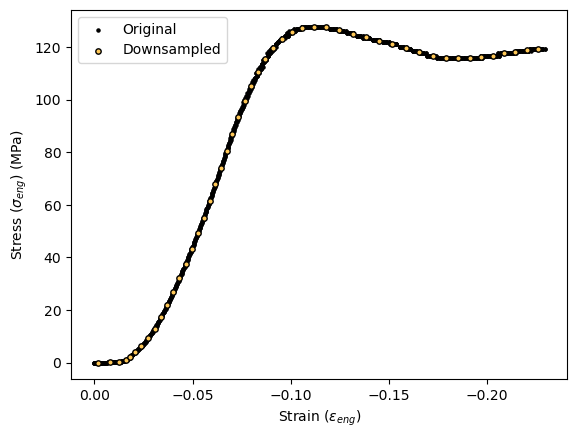

In [224]:
plt.figure()
plt.gca().invert_xaxis()
plt.scatter(OriginalStrain_arr,OriginalStress_arr,s=5,color="black",label="Original")
plt.scatter(DownsampledStrain_arr,DownsampledStress_arr,s=15,color="#ffc857",edgecolors="black",label="Downsampled")
plt.xlabel(r"Strain ($\epsilon_{eng}$)")
plt.ylabel(r"Stress ($\sigma_{eng}$) (MPa)")
plt.legend()

In [147]:
OriginalGradients = np.gradient(OriginalStress_arr)/np.gradient(OriginalStrain_arr)
DownsampledGradients = np.gradient(DownsampledStress_arr)/np.gradient(DownsampledStrain_arr)

/var/folders/mj/09q92gtx1tg0p9vt360nlyvm0000gn/T/ipykernel_23146/3580279934.py:1: RuntimeWarning: divide by zero encountered in divide
  OriginalGradients = np.gradient(OriginalStress_arr)/np.gradient(OriginalStrain_arr)
/var/folders/mj/09q92gtx1tg0p9vt360nlyvm0000gn/T/ipykernel_23146/3580279934.py:1: RuntimeWarning: invalid value encountered in divide
  OriginalGradients = np.gradient(OriginalStress_arr)/np.gradient(OriginalStrain_arr)


# Finding the Derivative of Stress with respect to Strain

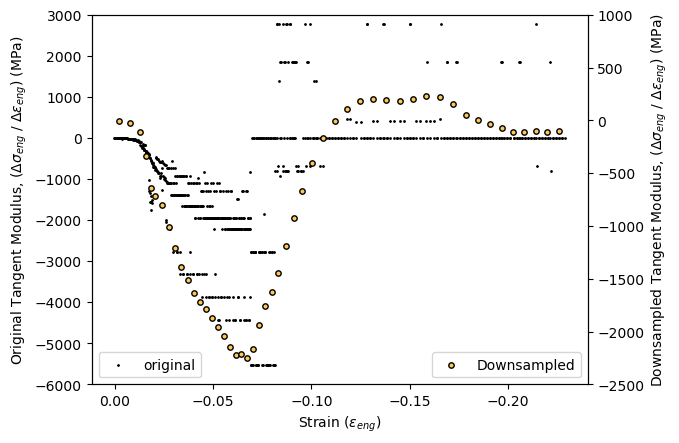

In [225]:
fig, ax1 = plt.subplots()
plt.gca().invert_xaxis()

ax1.scatter(OriginalStrain_arr,OriginalGradients,s=1,color="black",label="original")
ax1.set_xlabel(r"Strain ($\epsilon_{eng}$)")
ax1.set_ylabel(r"Original Tangent Modulus, ($\Delta \sigma_{eng}$ / $\Delta \epsilon_{eng}$) (MPa)")
ax1.set_ylim(ymin=-6000,ymax=3000)
# ax1.set_yticks([])
ax1.legend(loc="lower left")

ax2 = ax1.twinx()
ax2.scatter(DownsampledStrain_arr,DownsampledGradients,s=15,color="#ffc857",edgecolors="black",label="Downsampled")
ax2.set_ylim(ymin=-2500,ymax=1000)
ax2.set_ylabel(r"Downsampled Tangent Modulus, ($\Delta \sigma_{eng}$ / $\Delta \epsilon_{eng}$) (MPa)")
# ax2.set_yticks([])
ax2.legend(loc="lower right")

In [257]:
def InflectionFinder(DownsampledStrain_arr,DownsampledGradients,HorizonValue_int):
    """
    This function takes the compressive strength testing data array, and figures
    out the index position of the initial inflection point within the stress change vs
    strain graph, this locates a crucial position on the curve that can provide the
    young's modulus.
    Takes:
        cst_arr = numpy array, compressive strength test data array.
        HorizonValue_int = integer, the number of points backwards and forwards the algorithm can 'look'.
    Returns:
        InflectionIdx_int = integer, the index of the point which sits on the initial inflection.
    """
    import numpy as np
    strain_arr = DownsampledStrain_arr
    ForceDiff_arr = DownsampledGradients
    for counter,(strain,forcechange) in enumerate(zip(strain_arr,ForceDiff_arr)):
        if counter < HorizonValue_int:
            continue
        elif counter > (len(ForceDiff_arr) - (HorizonValue_int+1)):
            continue
        else:
            PrevIdx_arr = np.empty(shape=[0])
            FutIdx_arr = np.empty(shape=[0])
            for x in range(HorizonValue_int):
                PrevIdx_arr = np.append(PrevIdx_arr,(counter-(x+1)))
                FutIdx_arr = np.append(FutIdx_arr,(counter+(x+1)))
            PrevValsForceDiff = np.empty(shape=[0])
            for PrevIdx in PrevIdx_arr:
                PrevValsForceDiff = np.append(PrevValsForceDiff,ForceDiff_arr[int(PrevIdx)])
            FutValsForceDiff = np.empty(shape=[0])
            for FutIdx in FutIdx_arr:
                FutValsForceDiff = np.append(FutValsForceDiff,ForceDiff_arr[int(FutIdx)])
            AvgPrevValsForceDiff = np.average(PrevValsForceDiff)
            AvgFutValsForceDiff = np.average(FutValsForceDiff)
            if AvgPrevValsForceDiff < AvgFutValsForceDiff:
                InflectionIdx_int = counter
                return(InflectionIdx_int)

In [270]:
InflectionIdx_int = InflectionFinder(DownsampledStrain_arr,DownsampledGradients,HorizonValue_int=5)
print(InflectionIdx_int)

19


# Peak Finder

Iterates over the dataset from left to right.

At each point it looks five points forward and five points behind.

It evaluates the average tangent modulus ahead and behind for these points.

If the average tangent modulus in front becomes greater than the average behind then a halt is brought.

At this halt the current index of the peak is returned.

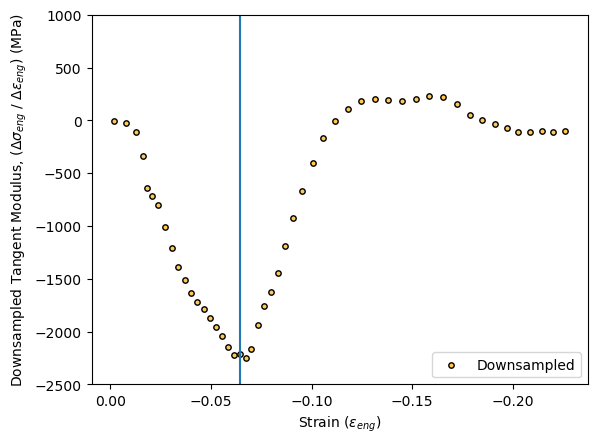

In [271]:
fig, ax1 = plt.subplots()
plt.gca().invert_xaxis()
ax1.set_xlabel(r"Strain ($\epsilon_{eng}$)")
ax1.scatter(DownsampledStrain_arr,DownsampledGradients,s=15,color="#ffc857",edgecolors="black",label="Downsampled")
ax1.set_ylim(ymin=-2500,ymax=1000)
ax1.set_ylabel(r"Downsampled Tangent Modulus, ($\Delta \sigma_{eng}$ / $\Delta \epsilon_{eng}$) (MPa)")
ax1.legend(loc="lower right")

ax1.axvline(x=DownsampledStrain_arr[InflectionIdx_int],ymin=-2500,ymax=1000)